# Notebook 2: U.S. CPI-U Inflation - Data Cleaning

**Source:** Kaggle - CPI for All Urban Consumers (CPI-U) | Average of all cities  
**Granularity:** Monthly (already - minimal transformation needed)  
**Scope:** 2020 - 2025  
**Columns:** `Yearmon` (date), `CPI`  

**Pipeline steps covered:** Data Ingestion --> Data Cleaning --> Data Wrangling

**Contributors**: Joan Ojukwu

## 1. Imports & Configuration

In [10]:
import pandas as pd               # loads and manipulates data tables
import numpy as np                # math operations
import matplotlib.pyplot as plt   # draws charts
import matplotlib.dates as mdates # formats date labels on chart axes
import os
import warnings # suppresses non-critical warnings

START_DATE = '2020-01-01'  # earliest date we want to keep
END_DATE   = '2025-12-31'  # latest date we want to keep
                           # (CPI only goes to Jul 2021)

print('Libraries loaded.')

Libraries loaded.


## 2. Data Ingestion

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
RAW_PATH = '/content/drive/MyDrive/DataSources&Manipulation/INST447-FinalProject/InputCSVfiles/USCPI2.csv'

df_raw = pd.read_csv(RAW_PATH)

print(f'Raw shape: {df_raw.shape}')
print(f'Columns  : {list(df_raw.columns)}') # confirms columns are 'Yearmon' and 'CPI'
df_raw.head(10)

Raw shape: (1303, 2)
Columns  : ['Yearmon', 'CPI']


,Yearmon,CPI
0,01-01-1913,9.8
1,01-02-1913,9.8
2,01-03-1913,9.8
3,01-04-1913,9.8
4,01-05-1913,9.7
5,01-06-1913,9.8
6,01-07-1913,9.9
7,01-08-1913,9.9
8,01-09-1913,10.0
9,01-10-1913,10.0


## 3. Initial Inspection

In [4]:
print('dtypes')
print(df_raw.dtypes)
print()
print('Missing values')
print(df_raw.isnull().sum())
print()
print('Descriptive stats')
print(df_raw.describe())

dtypes
Yearmon     object
CPI        float64
dtype: object

Missing values
Yearmon    0
CPI        0
dtype: int64

Descriptive stats
               CPI
count  1303.000000
mean     82.638309
std      80.369187
min       9.700000
25%      17.450000
50%      33.100000
75%     147.750000
max     273.003000


## 4. Date Parsing & Standardisation

The `Yearmon` column stores dates with day=1 for each month (e.g. `2020-01-01`).  
We convert to a proper `datetime` and set it as the index.

In [14]:
df = df_raw.copy() # work on a copy so the original stays untouched

DATE_COL = 'Yearmon'
# Fixed, added dayfirst=True because dates are formatted as DD-MM-YYYY
df[DATE_COL] = pd.to_datetime(df[DATE_COL], dayfirst=True)
# makes date the row label + sorts oldest to newest
df = df.set_index(DATE_COL).sort_index()
df.index.name = 'YearMonth'  # renames index to match the join key in other notebooks

# shifts each date to the last day of its month
# (ex: 2020-01-01 to 2020-01-31)
# required so all three datasets share exactly
# the same date format when merging
df.index = df.index + pd.offsets.MonthEnd(0)

print(f'Full date range: {df.index.min().date()} → {df.index.max().date()}')
df.head()

Full date range: 1913-01-31 → 2021-07-31


,CPI
YearMonth,
1913-01-31,9.8
1913-02-28,9.8
1913-03-31,9.8
1913-04-30,9.8
1913-05-31,9.7


## 5. Filter to Date Range of Interest

In [6]:
df = df.loc[START_DATE:END_DATE] # keeps only rows from 2020 onward
print(f'After date filter — shape: {df.shape}')
print(f'Date range: {df.index.min().date()} → {df.index.max().date()}')

After date filter — shape: (19, 1)
Date range: 2020-01-31 → 2021-07-31


## 6. Check for Missing Months

In [7]:
# builds a complete list of every month-end between start and end dates
expected_months = pd.date_range(start=START_DATE, end=END_DATE, freq='ME')
# finds which expected months are absent from the actual data
missing_months  = expected_months.difference(df.index)

if missing_months.empty:
    print('No missing months --> dataset is complete') # ideal
else:
    print(f'Missing months ({len(missing_months)}):') # lists any gaps
    print(missing_months)

# checks if any month appears more than once
dupes = df.index[df.index.duplicated()]
if dupes.empty:
    print('No duplicate months') # ideal
else:
    print(f'Duplicate months: {dupes}')

Missing months (53):
DatetimeIndex(['2021-08-31', '2021-09-30', '2021-10-31', '2021-11-30',
               '2021-12-31', '2022-01-31', '2022-02-28', '2022-03-31',
               '2022-04-30', '2022-05-31', '2022-06-30', '2022-07-31',
               '2022-08-31', '2022-09-30', '2022-10-31', '2022-11-30',
               '2022-12-31', '2023-01-31', '2023-02-28', '2023-03-31',
               '2023-04-30', '2023-05-31', '2023-06-30', '2023-07-31',
               '2023-08-31', '2023-09-30', '2023-10-31', '2023-11-30',
               '2023-12-31', '2024-01-31', '2024-02-29', '2024-03-31',
               '2024-04-30', '2024-05-31', '2024-06-30', '2024-07-31',
               '2024-08-31', '2024-09-30', '2024-10-31', '2024-11-30',
               '2024-12-31', '2025-01-31', '2025-02-28', '2025-03-31',
               '2025-04-30', '2025-05-31', '2025-06-30', '2025-07-31',
               '2025-08-31', '2025-09-30', '2025-10-31', '2025-11-30',
               '2025-12-31'],
              dtype='datet

## 7. Data Type & Range Validation

In [8]:
# confirms CPI is stored as a number
# 'coerce' turns any non-numeric values into NaN
df['CPI'] = pd.to_numeric(df['CPI'], errors='coerce')


CPI_MIN_EXPECTED = 200
CPI_MAX_EXPECTED = 350
# CPI-U for 2020-2021 should be in the 250-275 range
# these bounds catch obvious errors

bad_rows = df[(df['CPI'] < CPI_MIN_EXPECTED) | (df['CPI'] > CPI_MAX_EXPECTED)]
if bad_rows.empty:
    # confirms no encoding errors
    print(f'CPI values are within expected range ({CPI_MIN_EXPECTED}–{CPI_MAX_EXPECTED}).')
else:
    print(f'Unexpected CPI values ({len(bad_rows)} rows):')
    print(bad_rows)

CPI values are within expected range (200–350).


## 8. Derived Column: Month-over-Month Inflation Rate

We add a `Inflation_MoM_pct` column (% change from prior month) and `Inflation_YoY_pct`  
(% change from same month prior year).

These will be more useful than raw CPI in cross-channel analysis.

In [9]:
# MoM --> how much CPI changed compared to the previous month as a percentage
# pct_change(1) --> compare to 1 row back
# .mul(100) converts decimal to %
# .round(4) --> 4 decimal places
df['Inflation_MoM_pct'] = df['CPI'].pct_change(periods=1).mul(100).round(4)
# YoY --> how much CPI changed compared to the same month one year ago
# pct_change(12) --> compare to 12 rows back (like 12 months)
# First 12 rows will probabably be NaN because
# there's no prior year to compare to
df['Inflation_YoY_pct'] = df['CPI'].pct_change(periods=12).mul(100).round(4)

print('Derived columns added.')
df.head(15)

Derived columns added.


,CPI,Inflation_MoM_pct,Inflation_YoY_pct
YearMonth,,,
2020-01-31,257.971,NaN,NaN
2020-02-29,258.678,0.2741,NaN
2020-03-31,258.115,-0.2176,NaN
2020-04-30,256.389,-0.6687,NaN
2020-05-31,256.394,0.0020,NaN
2020-06-30,257.797,0.5472,NaN
2020-07-31,259.101,0.5058,NaN
2020-08-31,259.918,0.3153,NaN
2020-09-30,260.280,0.1393,NaN


## 9. Visualisation

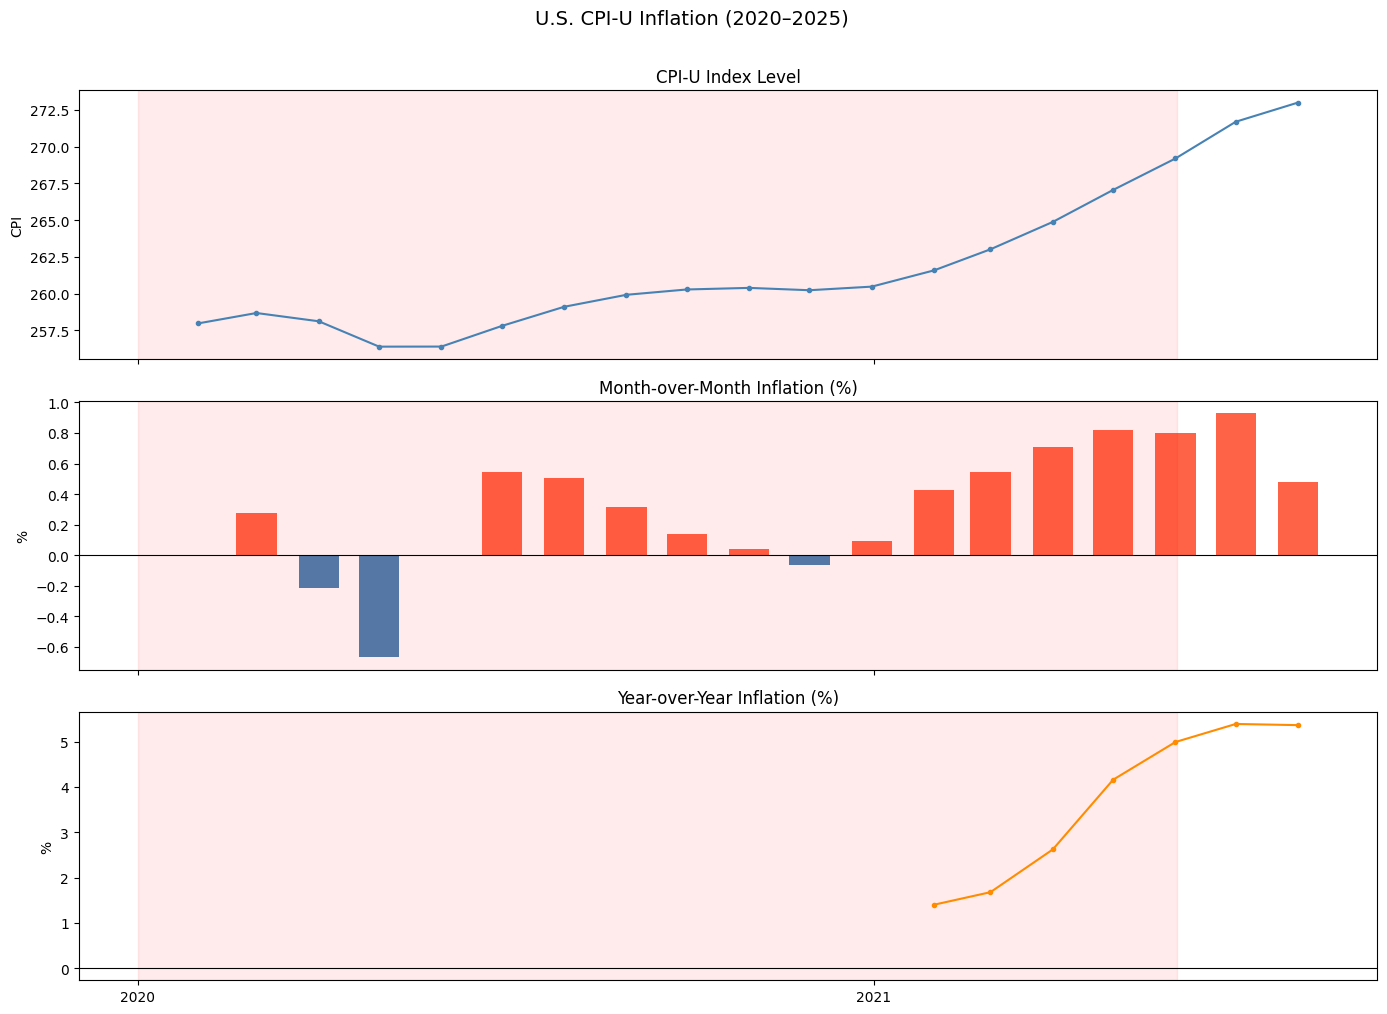

In [11]:
os.makedirs('figures', exist_ok=True) # creates figures/ folder
                                      # before trying to save
# creates 3 stacked subplots sharing the same x-axis (time)
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Top panel --> raw CPI index level over time
axes[0].plot(df.index, df['CPI'], lw=1.5, color='steelblue', marker='o', markersize=3)
axes[0].set_title('CPI-U Index Level')
axes[0].set_ylabel('CPI')

# Middle panel --> MoM inflation as a bar chart (red = pos, blue = neg)
axes[1].bar(df.index, df['Inflation_MoM_pct'],
            color=['tomato' if x > 0
                   else 'steelblue'
                   for x in df['Inflation_MoM_pct'].fillna(0)],
            width=20)
axes[1].axhline(0, color='black', lw=0.8) # horizontal line at zero for ref
axes[1].set_title('Month-over-Month Inflation (%)')
axes[1].set_ylabel('%')

# Bottom panel --> YoY inflation as a line chart
axes[2].plot(df.index, df['Inflation_YoY_pct'], lw=1.5, color='darkorange', marker='o', markersize=3)
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_title('Year-over-Year Inflation (%)')
axes[2].set_ylabel('%')

# shades the COVID period in light red across all three panels
for ax in axes:
    ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-06-01'),
               alpha=0.08, color='red', label='COVID period')

axes[-1].xaxis.set_major_locator(mdates.YearLocator()) # one tick per year on x-axis
# formats as just the year number
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('U.S. CPI-U Inflation (2020–2025)', fontsize=14, y=1.01)
plt.tight_layout()
# saves figure
plt.savefig('figures/cpi_inflation_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Final Validation & Save

In [12]:
print('Final dataset')
print(f'Shape      : {df.shape}')               # should be (19, 3) after fix
# 2020-01-31 --> 2021-07-31
print(f'Date range : {df.index.min().date()} → {df.index.max().date()}')
# MoM has 1 NaN (first row), YoY has 12
print(f'Nulls      : {df.isnull().sum().to_dict()}')
print()
print(df.describe())   # summary stats for all three columns

Final dataset
Shape      : (19, 3)
Date range : 2020-01-31 → 2021-07-31
Nulls      : {'CPI': 0, 'Inflation_MoM_pct': 1, 'Inflation_YoY_pct': 12}

              CPI  Inflation_MoM_pct  Inflation_YoY_pct
count   19.000000          18.000000           7.000000
mean   261.902895           0.315933           3.657886
std      4.991041           0.409922           1.734866
min    256.389000          -0.668700           1.399800
25%    258.396500           0.054650           2.148000
50%    260.280000           0.370350           4.159700
75%    263.945500           0.547350           5.179100
max    273.003000           0.929100           5.391500


In [13]:
OUT_PATH = '/content/drive/MyDrive/DataSources&Manipulation/INST447-FinalProject/OutputCSVFiles/cpi_inflation_monthly.csv'
df.to_csv(OUT_PATH)
print(f'Saved --> {OUT_PATH}')

Saved --> /content/drive/MyDrive/DataSources&Manipulation/INST447-FinalProject/OutputCSVFiles/cpi_inflation_monthly.csv


## 11. Cleaning Summary

| Step | Action | Rationale |
|------|--------|-----------|
| Date parse | `Yearmon` → `datetime` | Enables time-series indexing |
| Month-end offset | Shifted day-1 to month-end | Aligns join key with commodity & ship data |
| Date filter | 2020 → 2025 | Project scope |
| Missing month check | No gaps found | Confirmed completeness |
| CPI numeric validation | Range check 200–350 | Catches encoding or unit errors |
| MoM & YoY columns | Added | More interpretable for cross-channel analysis |

**Output:** `/content/drive/MyDrive/DataSources&Manipulation/INST447-FinalProject/OutputCSVFiles/cpi_inflation_monthly.csv`  
**Join key:** `YearMonth` (month-end date, e.g. `2020-01-31`)